In [1]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [2]:
with open('database_all_el7037.pkl', 'rb') as f:
    database = pickle.load(f)

## Correlaciones

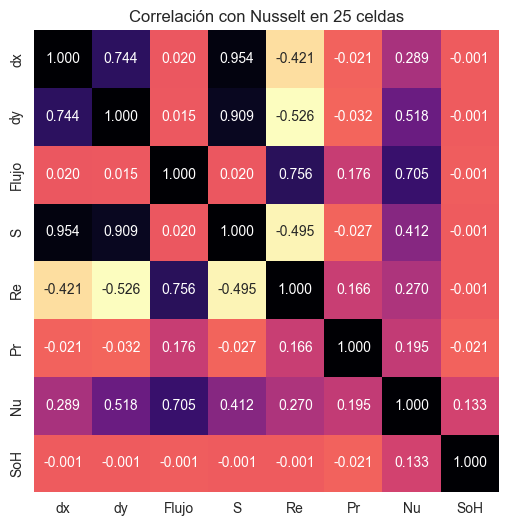

In [18]:
df = database[
    'nu'][25].drop(['q8', 'q10', 'q12', 'q14', 'Desgaste', 'n_cells',
                    'q2', 'q4', 'q6', 'colIndex', 'T_in'], axis=1).rename(
    {'nusselt': 'Nu', 'separation': 'S', 'Rem': 'Re', 'prandtl': 'Pr', 'F_in': 'Flujo'}, axis=1
)
# df = database['nu'][25][['nusselt', 'dx', 'dy', 'F_in', 'separation', 'Rem', 'prandtl', 'SoH']].rename(
#     {'separation': 'S', 'nusselt': 'Nu', 'prandtl': 'Pr', 'Rem': 'Re'}, axis=1
# )

plt.figure(figsize=(6, 6))
matrix_corr = np.corrcoef(df, rowvar=False)
sns.heatmap(matrix_corr, cmap='magma_r', xticklabels=df.columns, yticklabels=df.columns, annot=True, fmt='.3f', cbar=False)
plt.title('Correlación con Nusselt en 25 celdas')
plt.show()

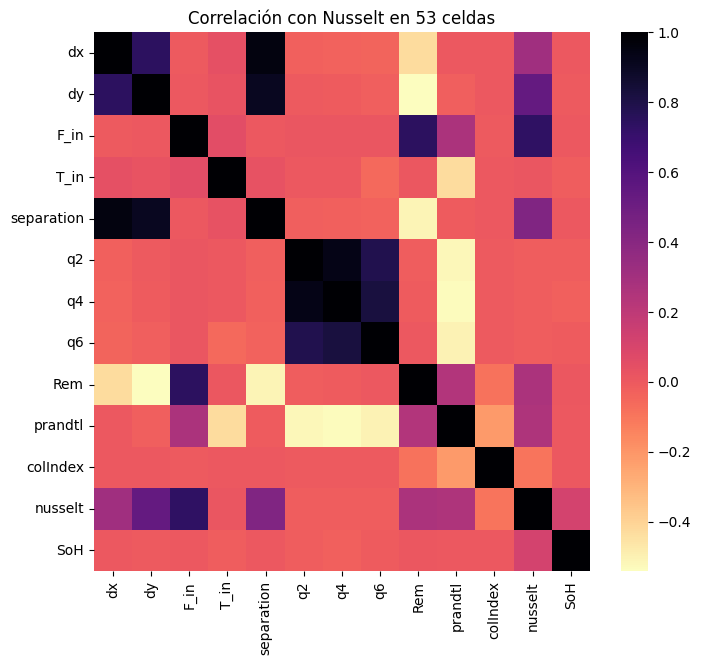

In [97]:
df = database['nu'][53].drop(['q8', 'q10', 'q12', 'q14', 'Desgaste', 'n_cells'], axis=1)
# df = database['nu'][53][['nusselt', 'dx', 'dy', 'F_in', 'separation', 'Rem', 'prandtl', 'SoH']].rename(
#     {'separation': 'S', 'nusselt': 'Nu', 'prandtl': 'Pr', 'Rem': 'Re'}, axis=1
# )

plt.figure(figsize=(8, 7))
matrix_corr = np.corrcoef(df, rowvar=False)
sns.heatmap(matrix_corr, cmap='magma_r', xticklabels=df.columns, yticklabels=df.columns)
plt.title('Correlación con Nusselt en 53 celdas')
plt.show()

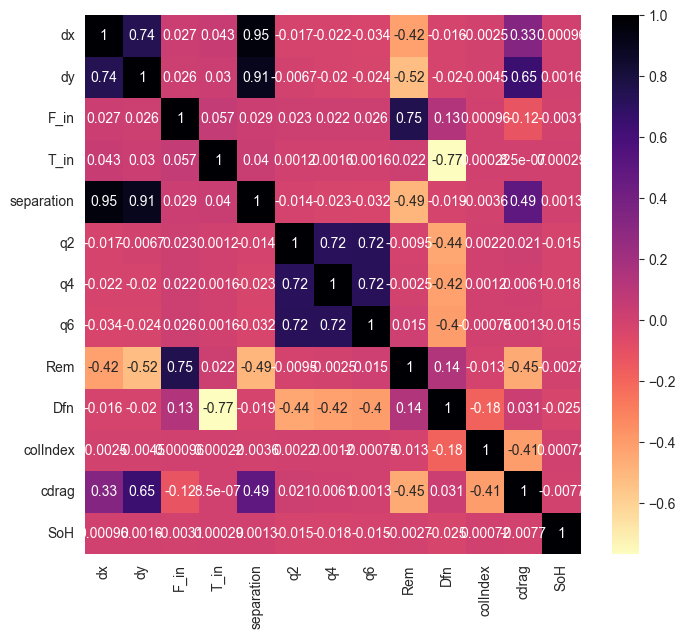

In [19]:
df = database['cdrag'][25].drop(['q8', 'q10', 'q12', 'q14', 'Desgaste', 'n_cells'], axis=1)

plt.figure(figsize=(8, 7))
matrix_corr = np.corrcoef(df, rowvar=False)
sns.heatmap(matrix_corr, cmap='magma_r', xticklabels=df.columns, yticklabels=df.columns, annot=True)
plt.show()

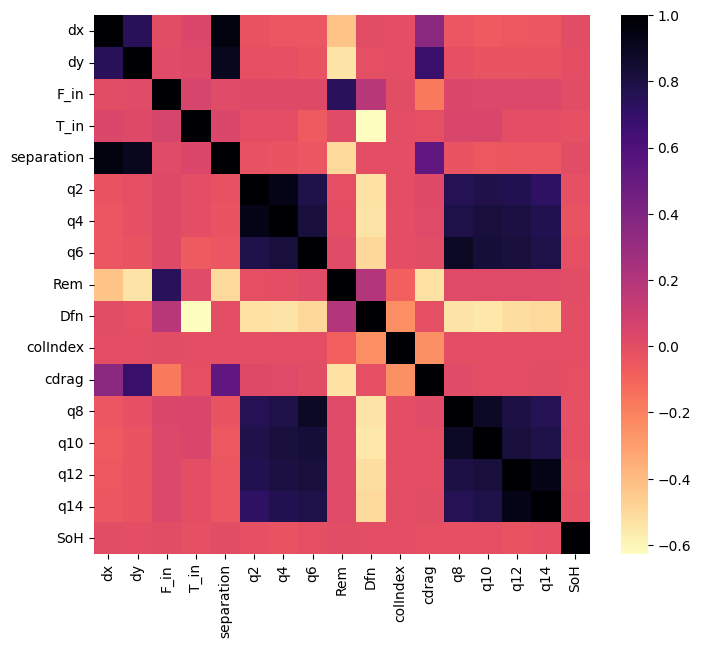

In [19]:
df = database['cdrag'][53].drop(['Desgaste', 'n_cells'], axis=1)

plt.figure(figsize=(8, 7))
matrix_corr = np.corrcoef(df, rowvar=False)
sns.heatmap(matrix_corr, cmap='magma_r', xticklabels=df.columns, yticklabels=df.columns)
plt.show()

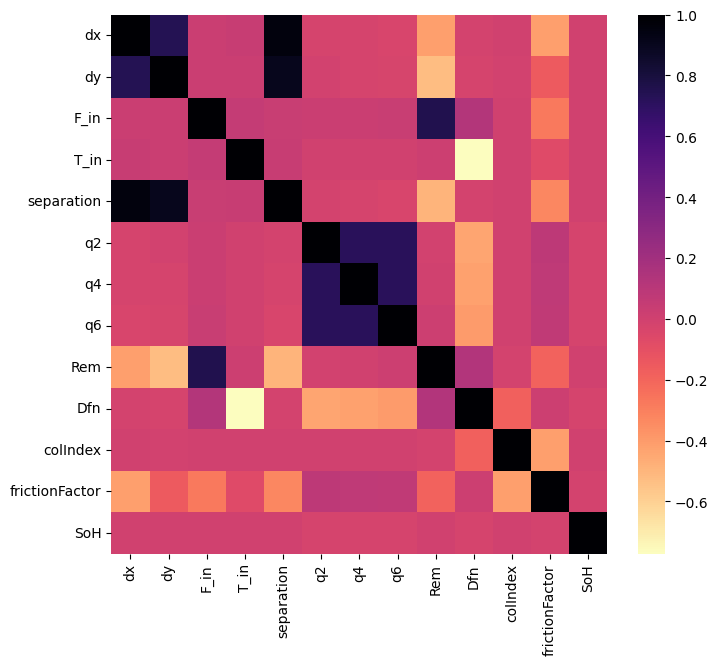

In [22]:
df = database['ff'][25].drop(['q8', 'q10', 'q12', 'q14', 'Desgaste', 'n_cells'], axis=1)

plt.figure(figsize=(8, 7))
matrix_corr = np.corrcoef(df, rowvar=False)
sns.heatmap(matrix_corr, cmap='magma_r', xticklabels=df.columns, yticklabels=df.columns)
plt.show()

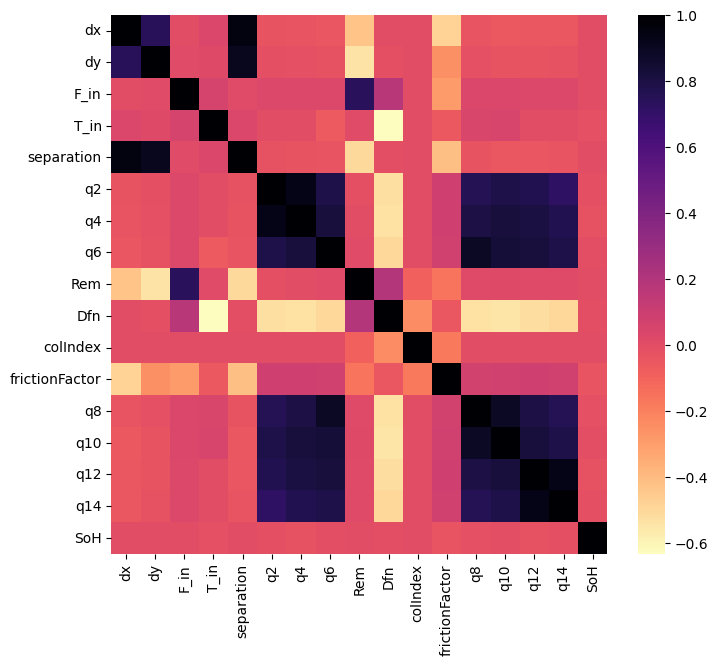

In [21]:
df = database['ff'][53].drop(['Desgaste', 'n_cells'], axis=1)

plt.figure(figsize=(8, 7))
matrix_corr = np.corrcoef(df, rowvar=False)
sns.heatmap(matrix_corr, cmap='magma_r', xticklabels=df.columns, yticklabels=df.columns)
plt.show()

## DB-SCAN

In [24]:
with open('database_random_el7037.pkl', 'rb') as f:
    database_random = pickle.load(f)

In [70]:
database_random['nu']['train'].columns

Index(['dx', 'dy', 'F_in', 'T_in', 'S', 'q2', 'q4', 'q6', 'Desgaste', 'Re',
       'prandtl', 'colIndex', 'nusselt', 'n_cells', 'q8', 'q10', 'q12', 'q14',
       'SoH'],
      dtype='object')

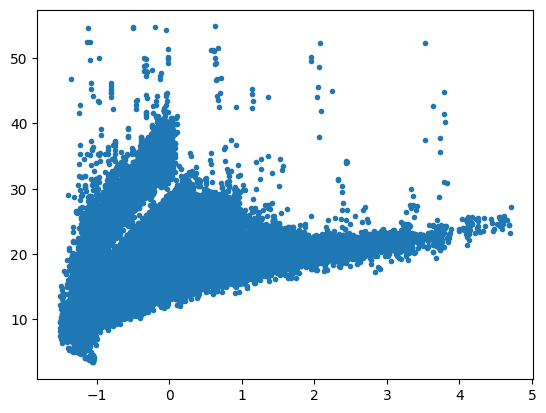

In [76]:
x_train = database_random['nu']['train'][['dx', 'dy', 'Re', 'prandtl', 'SoH']]
y_train = database_random['nu']['train']['nusselt']
xn_train = pd.DataFrame(StandardScaler().fit_transform(x_train), columns=x_train.columns)
plt.scatter(xn_train['Re'], y_train, marker='.')
plt.show()

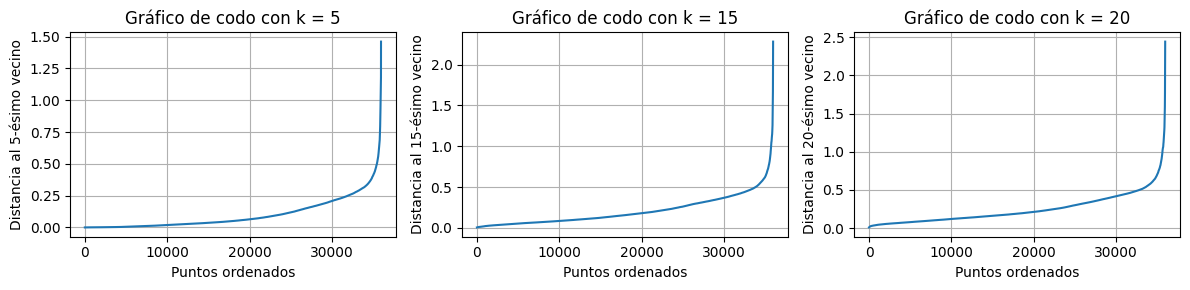

In [87]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

k = 5  # usado como min_samples en DBSCAN
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(xn_train)
distances, _ = neighbors_fit.kneighbors(xn_train)
k_distances = np.sort(distances[:, k - 1])  # Ordenar las distancias al k-ésimo vecino

ax[0].plot(k_distances)
ax[0].set_ylabel(f'Distancia al {k}-ésimo vecino')
ax[0].set_xlabel('Puntos ordenados')
ax[0].set_title(f'Gráfico de codo con k = {k}')
ax[0].grid(True)

k = 15  # usado como min_samples en DBSCAN
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(xn_train)
distances, _ = neighbors_fit.kneighbors(xn_train)
k_distances = np.sort(distances[:, k - 1])  # Ordenar las distancias al k-ésimo vecino

ax[1].plot(k_distances)
ax[1].set_ylabel(f'Distancia al {k}-ésimo vecino')
ax[1].set_xlabel('Puntos ordenados')
ax[1].set_title(f'Gráfico de codo con k = {k}')
ax[1].grid(True)

k = 20  # usado como min_samples en DBSCAN
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(xn_train)
distances, _ = neighbors_fit.kneighbors(xn_train)
k_distances = np.sort(distances[:, k - 1])  # Ordenar las distancias al k-ésimo vecino

ax[2].plot(k_distances)
ax[2].set_ylabel(f'Distancia al {k}-ésimo vecino')
ax[2].set_xlabel('Puntos ordenados')
ax[2].set_title(f'Gráfico de codo con k = {k}')
ax[2].grid(True)

plt.tight_layout()
plt.show()

In [88]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=0.5, min_samples=5).fit(x_train)
clusters = clustering.labels_
print('clusters =', np.unique(clusters).shape[0])
print(np.unique(clusters, return_counts=True))

clusters = 213
(array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
       142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
       168, 169, 170, 171, 172, 173, 174, 175, 1

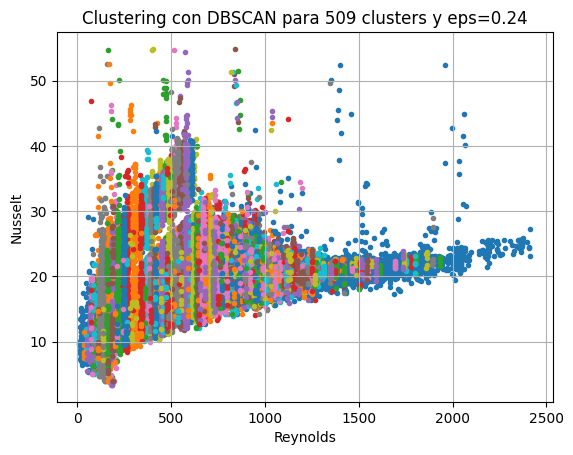

In [84]:
# Graficar cada cluster por separado
for i in np.unique(clusters):
    idx = clusters == i
    label = f'Cluster {i + 1}'
    plt.scatter(x_train['Re'][idx], y_train[idx], marker='.', label=label)

plt.grid()
plt.ylabel('Nusselt')
plt.xlabel('Reynolds')
plt.title(f'Clustering con DBSCAN para {np.unique(clusters).shape[0] - 1} clusters y eps={eps}')
plt.show()